**Image Classifier using Faster R-CNN model with a ResNet-50 backbone**

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.

Attempting to load dataset from: /content/drive/MyDrive/SPIE_Paper/PNG
Contents of /content/drive/MyDrive/SPIE_Paper/PNG:
- Ground Truth
- Original
Initializing dataset with root_dir: /content/drive/MyDrive/SPIE_Paper/PNG
Looking for images in: /content/drive/MyDrive/SPIE_Paper/PNG/Original
Looking for masks in: /content/drive/MyDrive/SPIE_Paper/PNG/Ground Truth
Found 612 valid image-mask pairs
Epoch 1/10
----------


100%|██████████| 245/245 [00:28<00:00,  8.60it/s]


Train Loss: 0.1529


100%|██████████| 62/62 [00:03<00:00, 15.97it/s]



Validation Metrics:
Precision: 0.5743
Recall: 0.8923
F1 Score: 0.6988
F1 score improved to 0.6988. Saving model...
Epoch 2/10
----------


...


Validation Metrics:
Precision: 0.9015
Recall: 0.9154
F1 Score: 0.9084
Epoch 10/10
----------


100%|██████████| 245/245 [00:25<00:00,  9.47it/s]


Train Loss: 0.0250


100%|██████████| 62/62 [00:03<00:00, 16.23it/s]



Validation Metrics:
Precision: 0.8897
Recall: 0.9308
F1 Score: 0.9098


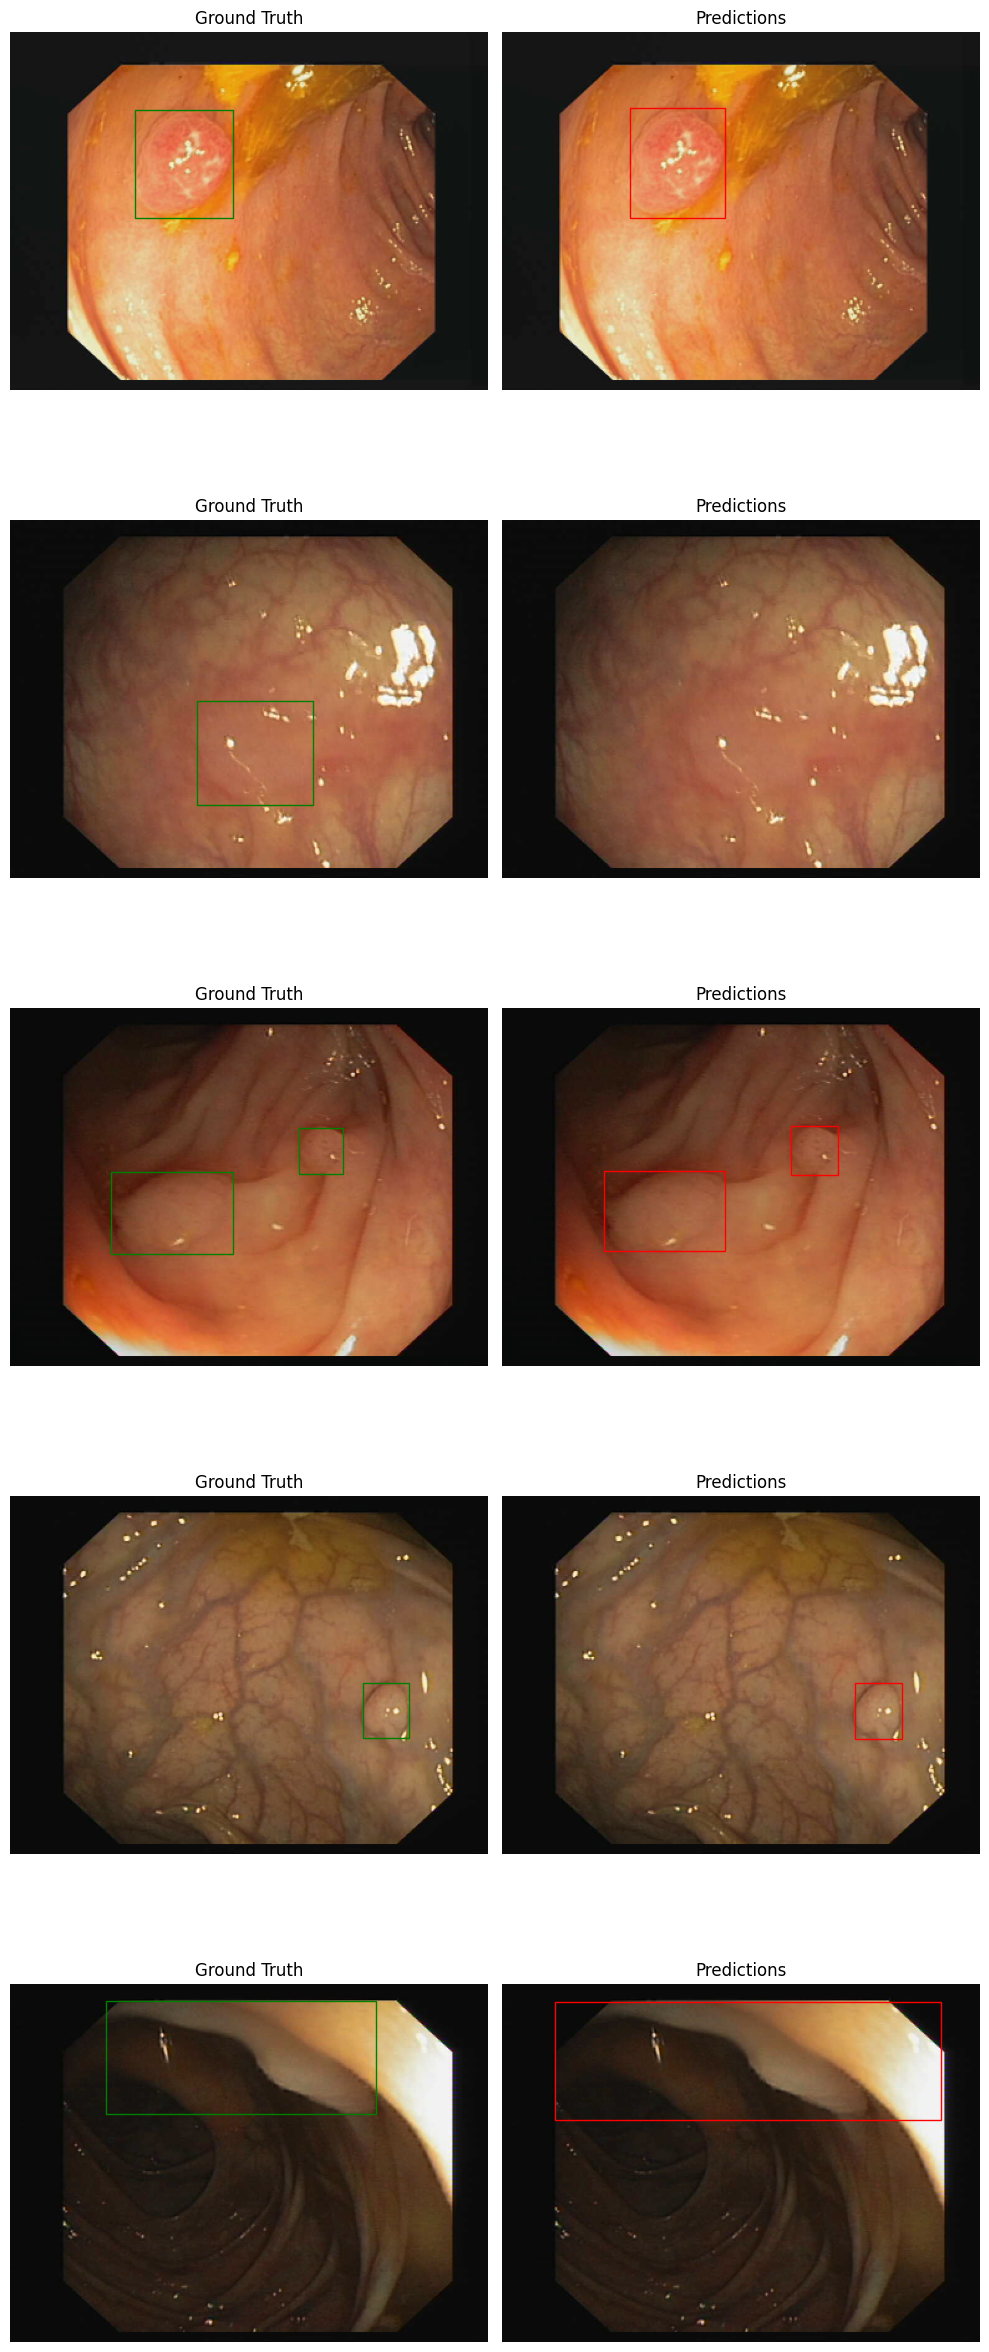

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive

def get_model(num_classes):
    """
    Initialize the Faster R-CNN model with a ResNet-50 backbone
    """
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

class CVCClinicDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """Initialize CVC-ClinicDB dataset"""
        self.root_dir = root_dir
        self.transform = transform

        print(f"Initializing dataset with root_dir: {root_dir}")

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Root directory not found: {root_dir}")

        self.image_dir = os.path.join(root_dir, 'Original')
        self.mask_dir = os.path.join(root_dir, 'Ground Truth')

        print(f"Looking for images in: {self.image_dir}")
        print(f"Looking for masks in: {self.mask_dir}")

        if not os.path.exists(self.image_dir):
            raise FileNotFoundError(f"Original images directory not found: {self.image_dir}")
        if not os.path.exists(self.mask_dir):
            raise FileNotFoundError(f"Ground Truth directory not found: {self.mask_dir}")

        self.images = []
        for f in sorted(os.listdir(self.image_dir)):
            if f.endswith('.tif') or f.endswith('.png'):
                if os.path.exists(os.path.join(self.mask_dir, f)):
                    self.images.append(f)
                else:
                    print(f"Warning: No matching mask found for image: {f}")

        print(f"Found {len(self.images)} valid image-mask pairs")
        if len(self.images) == 0:
            raise RuntimeError("No valid image-mask pairs found in dataset")

    def get_bounding_box(self, mask):
        """Get bounding box coordinates from segmentation mask"""
        mask = (mask > 128).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        boxes = []
        for contour in contours:
            if cv2.contourArea(contour) > 50:  # Minimum area threshold
                x, y, w, h = cv2.boundingRect(contour)
                boxes.append([x, y, x + w, y + h])
        return boxes

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image file not found: {img_path}")
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask file not found: {mask_path}")

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            raise Exception(f"Error loading image {img_path}: {str(e)}")

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise Exception(f"Error loading mask {mask_path}: OpenCV returned None")

        boxes = self.get_bounding_box(mask)

        if len(boxes) == 0:
            boxes = [[0, 0, 1, 1]]
            labels = torch.zeros(1, dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)

        if not isinstance(boxes, torch.Tensor):
            boxes = torch.as_tensor(boxes, dtype=torch.float32)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transform:
            image = self.transform(image)

        return image, target

def collate_fn(batch):
    """Custom collate function for the DataLoader"""
    return tuple(zip(*batch))

def train_one_epoch(model, optimizer, data_loader, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0

    for images, targets in tqdm(data_loader):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(data_loader)

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes"""
    # Get coordinates
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    # Calculate intersection coordinates
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)

    # Calculate areas
    intersection = max(0, x2_i - x1_i) * max(0, y2_i - y1_i)
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union = area1 + area2 - intersection

    return intersection / (union + 1e-7)  # Add small epsilon to avoid division by zero

@torch.no_grad()
def evaluate(model, data_loader, device, iou_threshold=0.5):
    """Evaluate the model using mean Average Precision"""
    model.eval()
    total_correct = 0
    total_predictions = 0
    total_ground_truth = 0

    for images, targets in tqdm(data_loader):
        images = [image.to(device) for image in images]

        # Get predictions
        outputs = model(images)

        # Process each image in the batch
        for output, target in zip(outputs, targets):
            pred_boxes = output['boxes'].cpu()
            pred_scores = output['scores'].cpu()
            gt_boxes = target['boxes']

            # Filter predictions by confidence
            mask = pred_scores > 0.5
            pred_boxes = pred_boxes[mask]

            # Count ground truths
            total_ground_truth += len(gt_boxes)

            # Count predictions
            total_predictions += len(pred_boxes)

            # Calculate matches using IoU
            for gt_box in gt_boxes:
                # Find best matching prediction
                best_iou = 0
                for pred_box in pred_boxes:
                    iou = calculate_iou(gt_box, pred_box)
                    best_iou = max(best_iou, iou)

                if best_iou >= iou_threshold:
                    total_correct += 1

    # Calculate metrics
    precision = total_correct / (total_predictions + 1e-7)
    recall = total_correct / (total_ground_truth + 1e-7)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

    print(f"\nValidation Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

    return f1_score  # Return F1 score as the validation metric

def train_model(model, train_loader, val_loader, optimizer, device, num_epochs=10):
    """Train the model with validation"""
    best_f1 = 0.0  # Higher F1 score is better

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 10)

        # Training phase
        train_loss = train_one_epoch(model, optimizer, train_loader, device)
        print(f"Train Loss: {train_loss:.4f}")

        # Validation phase
        f1_score = evaluate(model, val_loader, device)

        # Save model if F1 score improved
        if f1_score > best_f1:
            best_f1 = f1_score
            print(f"F1 score improved to {f1_score:.4f}. Saving model...")
            torch.save(model.state_dict(), 'best_model.pth')

    return model

def visualize_predictions(model, dataset, device, num_images=5):
    """Visualize model predictions"""
    model.eval()
    fig, axs = plt.subplots(num_images, 2, figsize=(10, num_images * 5))

    for i in range(num_images):
        image, target = dataset[i]

        with torch.no_grad():
            prediction = model([image.to(device)])

        image = image.permute(1, 2, 0).numpy()
        image = (image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
        image = np.clip(image, 0, 1)

        axs[i, 0].imshow(image)
        for box in target['boxes']:
            x1, y1, x2, y2 = box.numpy()
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='green')
            axs[i, 0].add_patch(rect)
        axs[i, 0].set_title('Ground Truth')
        axs[i, 0].axis('off')

        axs[i, 1].imshow(image)
        scores = prediction[0]['scores'].cpu().numpy()
        keep = scores > 0.5
        boxes = prediction[0]['boxes'][keep].cpu().numpy()

        for box in boxes:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red')
            axs[i, 1].add_patch(rect)
        axs[i, 1].set_title('Predictions')
        axs[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    try:
        drive.mount('/content/drive')
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Error mounting Google Drive: {e}")
        return

    dataset_path = '/content/drive/MyDrive/SPIE_Paper/PNG'
    print(f"\nAttempting to load dataset from: {dataset_path}")

    if os.path.exists(dataset_path):
        print(f"Contents of {dataset_path}:")
        for item in os.listdir(dataset_path):
            print(f"- {item}")
    else:
        print(f"The directory {dataset_path} does not exist.")
        return

    dataset = CVCClinicDataset(root_dir=dataset_path, transform=transform)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                            collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=collate_fn)

    model = get_model(num_classes=2)
    model = model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    model = train_model(model, train_loader, val_loader, optimizer, device)
    visualize_predictions(model, val_dataset, device)

if __name__ == "__main__":
    main()

**Polyp Detection Pre-trained Faster R-CNN model with a ResNet-50 backbone on Synthetic Images**


In [ ]:
import torch
import torchvision.transforms as transforms
import cv2
import os
from PIL import Image
import numpy as np
from datetime import datetime
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes=2):
    """Initialize the model"""
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def load_image(image_path):
    """Load and preprocess image"""
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    return transform(image), image

def create_output_dirs(base_path):
    """Create output directories for annotated images and text files"""
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    annotated_dir = os.path.join(base_path, f'annotated_images_{timestamp}')
    annotation_dir = os.path.join(base_path, f'annotations_{timestamp}')

    os.makedirs(annotated_dir, exist_ok=True)
    os.makedirs(annotation_dir, exist_ok=True)

    return annotated_dir, annotation_dir

def draw_boxes_and_save(original_image, boxes, scores, threshold, output_path):
    """Draw bounding boxes on image and save"""
    image_np = np.array(original_image)
    image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Draw each box that meets the confidence threshold
    for box, score in zip(boxes, scores):
        if score > threshold:
            x1, y1, x2, y2 = map(int, box)

            # Draw rectangle
            cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Add confidence score
            text = f"{score:.2f}"
            cv2.putText(image_np, text, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imwrite(output_path, image_np)

def save_annotations(boxes, scores, threshold, image_name, output_path):
    """Save detection results to text file"""
    with open(output_path, 'w') as f:
        f.write(f"Detection results for {image_name}\n")
        f.write("Format: <confidence> <x1> <y1> <x2> <y2>\n\n")

        for box, score in zip(boxes, scores):
            if score > threshold:
                x1, y1, x2, y2 = map(int, box)
                f.write(f"{score:.3f} {x1} {y1} {x2} {y2}\n")

def run_inference(model_path, image_dir, output_base_dir, conf_threshold=0.5):
    """Run inference on all images in directory"""
    # Set up device and model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = get_model()

    # Load trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # Create output directories
    annotated_dir, annotation_dir = create_output_dirs(output_base_dir)
    print(f"Saving annotated images to: {annotated_dir}")
    print(f"Saving text annotations to: {annotation_dir}")

    # Process each image
    total_images = len([f for f in os.listdir(image_dir)
                       if f.endswith(('.png', '.jpg', '.tif'))])
    processed = 0

    for image_name in os.listdir(image_dir):
        if not image_name.endswith(('.png', '.jpg', '.tif')):
            continue

        image_path = os.path.join(image_dir, image_name)

        try:
            # Load and preprocess image
            image_tensor, original_image = load_image(image_path)

            # Run inference
            with torch.no_grad():
                predictions = model([image_tensor.to(device)])

            # Get predictions
            pred_boxes = predictions[0]['boxes'].cpu().numpy()
            pred_scores = predictions[0]['scores'].cpu().numpy()

            # Save annotated image
            output_image_path = os.path.join(
                annotated_dir,
                f'annotated_{os.path.splitext(image_name)[0]}.png'
            )
            draw_boxes_and_save(original_image, pred_boxes, pred_scores,
                              conf_threshold, output_image_path)

            # Save text annotations
            output_text_path = os.path.join(
                annotation_dir,
                f'detection_{os.path.splitext(image_name)[0]}.txt'
            )
            save_annotations(pred_boxes, pred_scores, conf_threshold,
                           image_name, output_text_path)

            processed += 1
            print(f"Processed {processed}/{total_images}: {image_name}")

        except Exception as e:
            print(f"Error processing {image_name}: {str(e)}")
            continue

    print("\nInference completed!")
    print(f"Processed {processed} images")
    print(f"Annotated images saved to: {annotated_dir}")
    print(f"Text annotations saved to: {annotation_dir}")

if __name__ == "__main__":
    # Configuration
    model_path = 'best_model.pth'  # Path to your trained model
    image_dir = '/content/drive/MyDrive/SPIE_Paper/PNG/Original'  # Directory with images
    output_base_dir = '/content/drive/MyDrive/SPIE_Paper/Results'  # Base directory for results
    confidence_threshold = 0.5  # Confidence threshold for detections

    # Run inference
    run_inference(model_path, image_dir, output_base_dir, confidence_threshold)

<ipython-input-8-384f4336084e>:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Saving annotated images to: /content/drive/MyDrive/SPIE_Paper/Results/annotated_images_20250101_090632
Saving text annotations to: /content/drive/MyDrive/SPIE_Paper/Results/annotations_20250101_090632
Processed 1/612: 11.png
Processed 2/612: 103.png
Processed 3/612: 1.png
Processed 4/612: 10.png
Processed 5/612: 106.png
Processed 6/612: 101.png
Processed 7/612: 113.png
Processed 8/612: 105.png
Processed 9/612: 109.png
Processed 10/612: 102.png
Processed 11/612: 112.png
Processed 12/612: 110.png
Processed 13/612: 107.png
Processed 14/612: 104.png
Processed 15/612: 108.png
Processed 16/612: 111.png
Processed 17/612: 100.png
Processed 18/612: 120.png
Processed 19/612: 122.png
Processed 20/612: 121.png
Processed 21/612: 123.png
Processed 22/612: 129.png
Processed 23/612: 124.png
Processed 24/612: 116.png
Processed 25/612: 126.png
Processed 26/612: 118.png
Processed 27/612: 114.png
Processed 28/612: 117.png
Processed 29/612: 119.png
Processed 30/612: 128.png
Processed 31/612: 127.png
Proces

**POLYP DETECTION AND IMAGE ANNOTATION**


In [ ]:
import torch
import torchvision.transforms as transforms
import cv2
import os
from PIL import Image
import numpy as np
from datetime import datetime
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes=2):
    """Initialize the model"""
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def load_image(image_path):
    """Load and preprocess image"""
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    return transform(image), image

def create_output_dirs(base_path):
    """Create output directories for annotated images and text files"""
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    annotated_dir = os.path.join(base_path, f'annotated_images_{timestamp}')
    annotation_dir = os.path.join(base_path, f'annotations_{timestamp}')

    os.makedirs(annotated_dir, exist_ok=True)
    os.makedirs(annotation_dir, exist_ok=True)

    return annotated_dir, annotation_dir

def draw_boxes_and_save(original_image, boxes, scores, threshold, output_path):
    """Draw bounding boxes on image and save"""
    image_np = np.array(original_image)
    image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Draw each box that meets the confidence threshold
    for box, score in zip(boxes, scores):
        if score > threshold:
            x1, y1, x2, y2 = map(int, box)

            # Draw rectangle
            cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Add confidence score
            text = f"{score:.2f}"
            cv2.putText(image_np, text, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imwrite(output_path, image_np)

def save_annotations(boxes, scores, threshold, image_name, output_path):
    """Save detection results to text file"""
    with open(output_path, 'w') as f:
        f.write(f"Detection results for {image_name}\n")
        f.write("Format: <confidence> <x1> <y1> <x2> <y2>\n\n")

        for box, score in zip(boxes, scores):
            if score > threshold:
                x1, y1, x2, y2 = map(int, box)
                f.write(f"{score:.3f} {x1} {y1} {x2} {y2}\n")

def run_inference(model_path, image_dir, output_base_dir, conf_threshold=0.5):
    """Run inference on all images in directory"""
    # Set up device and model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = get_model()

    # Load trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # Create output directories
    annotated_dir, annotation_dir = create_output_dirs(output_base_dir)
    print(f"Saving annotated images to: {annotated_dir}")
    print(f"Saving text annotations to: {annotation_dir}")

    # Process each image
    total_images = len([f for f in os.listdir(image_dir)
                       if f.endswith(('.png', '.jpg', '.tif'))])
    processed = 0

    for image_name in os.listdir(image_dir):
        if not image_name.endswith(('.png', '.jpg', '.tif')):
            continue

        image_path = os.path.join(image_dir, image_name)

        try:
            # Load and preprocess image
            image_tensor, original_image = load_image(image_path)

            # Run inference
            with torch.no_grad():
                predictions = model([image_tensor.to(device)])

            # Get predictions
            pred_boxes = predictions[0]['boxes'].cpu().numpy()
            pred_scores = predictions[0]['scores'].cpu().numpy()

            # Save annotated image
            output_image_path = os.path.join(
                annotated_dir,
                f'annotated_{os.path.splitext(image_name)[0]}.png'
            )
            draw_boxes_and_save(original_image, pred_boxes, pred_scores,
                              conf_threshold, output_image_path)

            # Save text annotations
            output_text_path = os.path.join(
                annotation_dir,
                f'detection_{os.path.splitext(image_name)[0]}.txt'
            )
            save_annotations(pred_boxes, pred_scores, conf_threshold,
                           image_name, output_text_path)

            processed += 1
            print(f"Processed {processed}/{total_images}: {image_name}")

        except Exception as e:
            print(f"Error processing {image_name}: {str(e)}")
            continue

    print("\nInference completed!")
    print(f"Processed {processed} images")
    print(f"Annotated images saved to: {annotated_dir}")
    print(f"Text annotations saved to: {annotation_dir}")

if __name__ == "__main__":
    # Configuration
    model_path = 'best_model.pth'  # Path to your trained model
    image_dir = '/content/drive/MyDrive/SPIE_Paper/synthetic'  # Directory with images
    output_base_dir = '/content/drive/MyDrive/SPIE_Paper/Results'  # Base directory for results
    confidence_threshold = 0.5  # Confidence threshold for detections

    # Run inference
    run_inference(model_path, image_dir, output_base_dir, confidence_threshold)

<ipython-input-9-1df7ed07a6c5>:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Saving annotated images to: /content/drive/MyDrive/SPIE_Paper/Results/annotated_images_20250101_094456
Saving text annotations to: /content/drive/MyDrive/SPIE_Paper/Results/annotations_20250101_094456
Processed 1/1800: gen-finetuned-1053.png
Processed 2/1800: gen-finetuned-1078.png
Processed 3/1800: gen-finetuned-1074.png
Processed 4/1800: gen-finetuned-1067.png
Processed 5/1800: gen-finetuned-1073.png
Processed 6/1800: gen-finetuned-1069.png
Processed 7/1800: gen-finetuned-107.png
Processed 8/1800: gen-finetuned-1066.png
Processed 9/1800: gen-finetuned-1070.png
Processed 10/1800: gen-finetuned-1063.png
Processed 11/1800: gen-finetuned-1075.png
Processed 12/1800: gen-finetuned-1062.png
Processed 13/1800: gen-finetuned-1056.png
Processed 14/1800: gen-finetuned-1059.png
Processed 15/1800: gen-finetuned-1061.png
Processed 16/1800: gen-finetuned-1055.png
Processed 17/1800: gen-finetuned-1052.png
Processed 18/1800: gen-finetuned-1058.png
Processed 19/1800: gen-finetuned-1064.png
Processed 2

**IMAGE MASK GENERATION USING SAM **

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-tbprq10l
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-tbprq10l
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=66970dfc4ab5dd3662eef1704e4790d70a338941f14cfbaee1d705cbbe3d5139
  Stored in directory: /tmp/pip-ephem-wheel-cache-a_rrxyha/wheels/10/cf/59/9ccb2f0a1bcc81d4fbd0e501680b5d088d690c6cfbc02dc99d
Successfully built segment_anything


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2025-01-01 09:53:31--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.68, 3.171.22.33, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   350MB/s    in 7.2s    

2025-01-01 09:53:38 (338 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
import torch
import numpy as np
import cv2
from PIL import Image
import os
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.pyplot as plt
from tqdm import tqdm

class SAMMaskGenerator:
    def __init__(self, sam_checkpoint):
        """
        Initialize SAM mask generator
        Args:
            sam_checkpoint (str): Path to SAM model checkpoint
        """
        # Initialize SAM
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model_type = "vit_h"  # or "vit_l" or "vit_b" depending on your checkpoint

        sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
        sam.to(device=device)

        self.predictor = SamPredictor(sam)

    def read_annotations(self, annotation_file):
        """
        Read bounding box annotations from text file
        Args:
            annotation_file (str): Path to annotation text file
        Returns:
            list: List of [confidence, x1, y1, x2, y2] for each detection
        """
        annotations = []
        with open(annotation_file, 'r') as f:
            lines = f.readlines()
            # Skip header lines
            for line in lines[2:]:
                if line.strip():
                    conf, x1, y1, x2, y2 = map(float, line.strip().split())
                    annotations.append([conf, int(x1), int(y1), int(x2), int(y2)])
        return annotations

    def generate_mask(self, image_path, boxes, confidence_threshold=0.5):
        """
        Generate mask for an image using SAM
        Args:
            image_path (str): Path to input image
            boxes (list): List of [confidence, x1, y1, x2, y2] annotations
            confidence_threshold (float): Minimum confidence for processing a box
        Returns:
            combined_mask (np.ndarray): Binary mask combining all polyp detections
        """
        # Read image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Set image in predictor
        self.predictor.set_image(image)

        # Initialize combined mask
        combined_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Process each bounding box
        for box in boxes:
            confidence = box[0]
            if confidence < confidence_threshold:
                continue

            # Extract box coordinates
            x1, y1, x2, y2 = map(int, box[1:])
            box_np = np.array([x1, y1, x2, y2])

            # Generate mask for this box
            masks, scores, _ = self.predictor.predict(
                box=box_np,
                multimask_output=True
            )

            # Use the mask with highest score
            best_mask = masks[scores.argmax()].astype(np.uint8)

            # Combine with existing mask (union)
            combined_mask = np.logical_or(combined_mask, best_mask).astype(np.uint8)

        return combined_mask * 255  # Convert to 8-bit mask

    def save_visualization(self, image_path, mask, output_path):
        """
        Save visualization of the mask overlaid on the image
        """
        # Read image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create visualization
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

        # Original image
        ax1.imshow(image)
        ax1.set_title('Original Image')
        ax1.axis('off')

        # Mask
        ax2.imshow(mask, cmap='gray')
        ax2.set_title('Generated Mask')
        ax2.axis('off')

        # Overlay
        overlay = image.copy()
        overlay[mask > 0] = (0, 255, 0)  # Green overlay for mask
        ax3.imshow(overlay)
        ax3.set_title('Overlay')
        ax3.axis('off')

        plt.tight_layout()
        plt.savefig(output_path)
        plt.close()

def process_dataset(sam_checkpoint, annotated_dir, annotation_dir, output_dir):
    """
    Process entire dataset to generate masks
    Args:
        sam_checkpoint (str): Path to SAM model checkpoint
        annotated_dir (str): Directory containing annotated images
        annotation_dir (str): Directory containing annotation text files
        output_dir (str): Directory to save generated masks and visualizations
    """
    # Create output directories
    mask_dir = os.path.join(output_dir, 'masks')
    vis_dir = os.path.join(output_dir, 'visualizations')
    os.makedirs(mask_dir, exist_ok=True)
    os.makedirs(vis_dir, exist_ok=True)

    # Initialize SAM mask generator
    mask_generator = SAMMaskGenerator(sam_checkpoint)

    # Get list of annotation files
    annotation_files = [f for f in os.listdir(annotation_dir)
                       if f.startswith('detection_') and f.endswith('.txt')]

    print(f"Found {len(annotation_files)} annotation files")

    # Process each file
    for ann_file in tqdm(annotation_files):
        try:
            # Get corresponding image file
            image_base = ann_file.replace('detection_', 'annotated_').replace('.txt', '.png')
            image_path = os.path.join(annotated_dir, image_base)

            if not os.path.exists(image_path):
                print(f"Warning: Image not found for {ann_file}")
                continue

            # Read annotations
            annotations = mask_generator.read_annotations(
                os.path.join(annotation_dir, ann_file)
            )

            # Generate mask
            mask = mask_generator.generate_mask(image_path, annotations)

            # Save mask
            mask_path = os.path.join(mask_dir,
                                   f"mask_{os.path.splitext(image_base)[0]}.png")
            cv2.imwrite(mask_path, mask)

            # Save visualization
            vis_path = os.path.join(vis_dir,
                                  f"vis_{os.path.splitext(image_base)[0]}.png")
            mask_generator.save_visualization(image_path, mask, vis_path)

        except Exception as e:
            print(f"Error processing {ann_file}: {str(e)}")
            continue

    print("\nProcessing completed!")
    print(f"Masks saved to: {mask_dir}")
    print(f"Visualizations saved to: {vis_dir}")

if __name__ == "__main__":
    # Configuration
    sam_checkpoint = "sam_vit_h_4b8939.pth"  # Download from Meta's repository
    annotated_dir = '/content/drive/MyDrive/SPIE_Paper/Results/annotated_images_20250101_094456'
    annotation_dir = '/content/drive/MyDrive/SPIE_Paper/Results/annotations_20250101_094456'
    output_dir = '/content/drive/MyDrive/SPIE_Paper/SAM_Results'

    # Run processing
    process_dataset(sam_checkpoint, annotated_dir, annotation_dir, output_dir)

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Found 1800 annotation files


100%|██████████| 1800/1800 [27:52<00:00,  1.08it/s]


Processing completed!
Masks saved to: /content/drive/MyDrive/SPIE_Paper/SAM_Results/masks
Visualizations saved to: /content/drive/MyDrive/SPIE_Paper/SAM_Results/visualizations


**TRAINING FIVE (5) IMAGE SEGMENTATION MODELS**

In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=de6f3bbe69f0603b4665b96c0f3511ac70b30849b9210b44dba38ebce3f6000d
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=66a53780dfd45a431c47ec24d9fed0f328d3f48f739608d8634e477ad2acb86f
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch

In [ ]:
!pip install efficientnet-pytorch
!pip install torch-optimizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from collections import defaultdict
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

class PolypsDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        """
        Args:
            img_dir (str): Directory with all the images
            mask_dir (str): Directory with all the masks
            transform (callable, optional): Optional transform to be applied
        """
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Get sorted list of files
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.tif'))])
        self.masks = [f'mask_annotated_{img}' for img in self.images]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and mask
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        # Read image and convert to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Normalize mask to [0, 1]
        mask = mask / 255.0

        # Add channel dimension to mask
        if len(mask.shape) == 2:
            mask = mask[None]

        return image, mask.float()

class SegmentationLoss(nn.Module):
    def __init__(self, weights=[0.3, 0.4, 0.3]):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary')
        self.focal = smp.losses.FocalLoss(mode='binary')
        self.weights = weights

    def forward(self, y_pred, y_true):
        bce = self.bce(y_pred, y_true)
        dice = self.dice(y_pred, y_true)
        focal = self.focal(y_pred, y_true)
        return self.weights[0] * bce + self.weights[1] * dice + self.weights[2] * focal

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.5),
            A.OneOf([
                A.ElasticTransform(p=1),
                A.GridDistortion(p=1),
                A.OpticalDistortion(p=1)
            ], p=0.3),
            A.OneOf([
                A.GaussNoise(p=1),
                A.RandomBrightnessContrast(p=1),
                A.RandomGamma(p=1)
            ], p=0.3),
            A.Normalize(),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, num_epochs=50, scheduler=None):
    """Train the model"""
    print(f'Using device: {device}')

    # Initialize GradScaler for mixed precision training
    scaler = GradScaler()

    # Initialize best model tracking
    best_val_loss = float('inf')
    best_val_metrics = None
    best_model_state = None

    # Training history
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc='Training'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            # Use mixed precision training
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        metrics = defaultdict(float)

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validation'):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                # Calculate additional metrics
                pred_masks = (torch.sigmoid(outputs) > 0.5).float()
                batch_metrics = calculate_metrics(pred_masks.cpu().numpy(),
                                               masks.cpu().numpy())

                for k, v in batch_metrics.items():
                    metrics[k] += v

        val_loss = val_loss / len(val_loader)
        metrics = {k: v/len(val_loader) for k, v in metrics.items()}

        # Update learning rate
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}')
        print(f'Val Loss: {val_loss:.4f}')
        for k, v in metrics.items():
            print(f'Val {k}: {v:.4f}')

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for k, v in metrics.items():
            history[f'val_{k}'].append(v)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_metrics = metrics
            best_model_state = model.state_dict().copy()

            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'val_metrics': best_val_metrics,
            }, 'best_model.pth')

    return history, best_model_state, best_val_metrics

def calculate_metrics(y_pred, y_true):
    """Calculate various segmentation metrics"""
    eps = 1e-7

    # Ensure binary masks
    y_pred_binary = (y_pred > 0.5).astype(np.uint8)
    y_true_binary = (y_true > 0.5).astype(np.uint8)

    # Reshape for metric calculation
    y_pred_flat = y_pred_binary.reshape(-1)
    y_true_flat = y_true_binary.reshape(-1)

    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, average='binary', zero_division=0)

    # Calculate IoU
    intersection = np.logical_and(y_true_binary, y_pred_binary).sum()
    union = np.logical_or(y_true_binary, y_pred_binary).sum()
    iou = (intersection + eps) / (union + eps)

    # Calculate PSNR
    try:
        psnr_value = psnr(y_true, y_pred, data_range=1.0)
    except:
        psnr_value = 0

    # Calculate SSIM
    try:
        ssim_value = ssim(y_true.squeeze(), y_pred.squeeze(), data_range=1.0)
    except:
        ssim_value = 0

    # Calculate Dice coefficient
    dice = (2. * intersection + eps) / (y_true_binary.sum() + y_pred_binary.sum() + eps)

    return {
        'IoU': float(iou),
        'Dice': float(dice),
        'Precision': float(precision),
        'Recall': float(recall),
        'F1': float(f1),
        'PSNR': float(psnr_value),
        'SSIM': float(ssim_value)
    }

def plot_training_history(history):
    """Plot training history"""
    plt.figure(figsize=(15, 5))

    # Plot losses
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot metrics
    plt.subplot(1, 2, 2)
    metrics = [k for k in history.keys() if k.startswith('val_') and k != 'val_loss']
    for metric in metrics:
        plt.plot(history[metric], label=metric[4:])
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()

def setup_ssl_context():
    """Setup SSL context to handle certificate issues"""
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    print("SSL certificate verification disabled for model downloads")

def main():
    # Setup SSL context for downloads
    setup_ssl_context()

    # Configuration
    img_dir = '/content/drive/MyDrive/SPIE_Paper/synthetic'
    mask_dir = '/content/drive/MyDrive/SPIE_Paper/masks'
    batch_size = 8
    num_epochs = 50
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create datasets with augmentations
    train_transform = get_transforms(train=True)
    val_transform = get_transforms(train=False)

    dataset = PolypsDataset(img_dir, mask_dir, transform=train_transform)

    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)

    # Initialize models dictionary with more stable configurations
    models = {
        'UNet': smp.Unet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'PSPNet': smp.PSPNet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'FPN': smp.FPN(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'LinkNet': smp.Linknet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'MANet': smp.MAnet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        )
    }

    # Print model loading confirmation
    print("Models initialized with ResNet34 backbone")

    # Results dictionary to store metrics for each model
    results = {}

    # Train each model
    for model_name, model in models.items():
        print(f'\nTraining {model_name}...')
        model = model.to(device)

        # Initialize criterion, optimizer and scheduler
        criterion = SegmentationLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True)

        # Train model
        history, best_weights, best_metrics = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            device, num_epochs, scheduler)

        # Save results
        results[model_name] = {
            'history': history,
            'best_metrics': best_metrics
        }

        # Plot training history
        plot_training_history(history)

        # Save model weights
        torch.save(best_weights, f'best_{model_name.lower()}_model.pth')

    # Save results to CSV
    results_df = pd.DataFrame()
    for model_name, result in results.items():
        metrics = result['best_metrics']
        metrics['Model'] = model_name
        results_df = results_df.append(metrics, ignore_index=True)

    results_df.to_csv('model_comparison.csv', index=False)
    print("\nTraining completed! Results saved to 'model_comparison.csv'")

if __name__ == '__main__':
    main()

SSL certificate verification disabled for model downloads


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
<ipython-input-21-d680ed7d3ac1>:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Models initialized with ResNet34 backbone

Training UNet...
Using device: cuda

Epoch 1/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-21-d680ed7d3ac1>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.91it/s]


Train Loss: 0.3621
Val Loss: 0.3266
Val IoU: 0.6345
Val Dice: 0.7731
Val Precision: 0.7137
Val Recall: 0.8501
Val F1: 0.7731
Val PSNR: 6.4102
Val SSIM: 0.3934

Epoch 2/50
----------


...

Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-21-d680ed7d3ac1>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:08<00:00,  5.56it/s]


Train Loss: 0.2119
Val Loss: 0.3045
Val IoU: 0.6596
Val Dice: 0.7908
Val Precision: 0.7853
Val Recall: 0.8109
Val F1: 0.7908
Val PSNR: 7.1537
Val SSIM: 0.4977

Epoch 50/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-21-d680ed7d3ac1>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.63it/s]


Train Loss: 0.2183
Val Loss: 0.2986
Val IoU: 0.6544
Val Dice: 0.7867
Val Precision: 0.7847
Val Recall: 0.7997
Val F1: 0.7867
Val PSNR: 7.1396
Val SSIM: 0.4868


AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from collections import defaultdict
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

class PolypsDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        """
        Args:
            img_dir (str): Directory with all the images
            mask_dir (str): Directory with all the masks
            transform (callable, optional): Optional transform to be applied
        """
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Get sorted list of files
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.tif'))])
        self.masks = [f'mask_annotated_{img}' for img in self.images]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and mask
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        # Read image and convert to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Normalize mask to [0, 1]
        mask = mask / 255.0

        # Add channel dimension to mask
        if len(mask.shape) == 2:
            mask = mask[None]

        return image, mask.float()

class SegmentationLoss(nn.Module):
    def __init__(self, weights=[0.3, 0.4, 0.3]):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary')
        self.focal = smp.losses.FocalLoss(mode='binary')
        self.weights = weights

    def forward(self, y_pred, y_true):
        bce = self.bce(y_pred, y_true)
        dice = self.dice(y_pred, y_true)
        focal = self.focal(y_pred, y_true)
        return self.weights[0] * bce + self.weights[1] * dice + self.weights[2] * focal

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.5),
            A.OneOf([
                A.ElasticTransform(p=1),
                A.GridDistortion(p=1),
                A.OpticalDistortion(p=1)
            ], p=0.3),
            A.OneOf([
                A.GaussNoise(p=1),
                A.RandomBrightnessContrast(p=1),
                A.RandomGamma(p=1)
            ], p=0.3),
            A.Normalize(),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, num_epochs=50, scheduler=None):
    """Train the model"""
    print(f'Using device: {device}')

    # Initialize GradScaler for mixed precision training
    scaler = GradScaler()

    # Initialize best model tracking
    best_val_loss = float('inf')
    best_val_metrics = None
    best_model_state = None

    # Training history
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc='Training'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            # Use mixed precision training
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        metrics = defaultdict(float)

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validation'):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                # Calculate additional metrics
                pred_masks = (torch.sigmoid(outputs) > 0.5).float()
                batch_metrics = calculate_metrics(pred_masks.cpu().numpy(),
                                               masks.cpu().numpy())

                for k, v in batch_metrics.items():
                    metrics[k] += v

        val_loss = val_loss / len(val_loader)
        metrics = {k: v/len(val_loader) for k, v in metrics.items()}

        # Update learning rate
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}')
        print(f'Val Loss: {val_loss:.4f}')
        for k, v in metrics.items():
            print(f'Val {k}: {v:.4f}')

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for k, v in metrics.items():
            history[f'val_{k}'].append(v)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_metrics = metrics
            best_model_state = model.state_dict().copy()

            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'val_metrics': best_val_metrics,
            }, 'best_model.pth')

    return history, best_model_state, best_val_metrics

def calculate_metrics(y_pred, y_true):
    """Calculate various segmentation metrics"""
    eps = 1e-7

    # Ensure binary masks
    y_pred_binary = (y_pred > 0.5).astype(np.uint8)
    y_true_binary = (y_true > 0.5).astype(np.uint8)

    # Reshape for metric calculation
    y_pred_flat = y_pred_binary.reshape(-1)
    y_true_flat = y_true_binary.reshape(-1)

    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, average='binary', zero_division=0)

    # Calculate IoU
    intersection = np.logical_and(y_true_binary, y_pred_binary).sum()
    union = np.logical_or(y_true_binary, y_pred_binary).sum()
    iou = (intersection + eps) / (union + eps)

    # Calculate PSNR
    try:
        psnr_value = psnr(y_true, y_pred, data_range=1.0)
    except:
        psnr_value = 0

    # Calculate SSIM
    try:
        ssim_value = ssim(y_true.squeeze(), y_pred.squeeze(), data_range=1.0)
    except:
        ssim_value = 0

    # Calculate Dice coefficient
    dice = (2. * intersection + eps) / (y_true_binary.sum() + y_pred_binary.sum() + eps)

    return {
        'IoU': float(iou),
        'Dice': float(dice),
        'Precision': float(precision),
        'Recall': float(recall),
        'F1': float(f1),
        'PSNR': float(psnr_value),
        'SSIM': float(ssim_value)
    }

def plot_training_history(history, model_name):
    """Plot training history for a specific model"""
    # Create figure directory if it doesn't exist
    os.makedirs('training_plots', exist_ok=True)

    # Create separate plots for loss and metrics
    plt.figure(figsize=(15, 5))

    # Plot losses
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot metrics
    plt.subplot(1, 2, 2)
    metrics = [k for k in history.keys() if k.startswith('val_') and k != 'val_loss']
    for metric in metrics:
        plt.plot(history[metric], label=metric[4:])
    plt.title(f'{model_name} Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()

    # Save plots
    plot_path = os.path.join('training_plots', f'{model_name.lower()}_training_history.png')
    plt.savefig(plot_path)
    plt.close()

    # Also save individual metric plots
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    loss_plot_path = os.path.join('training_plots', f'{model_name.lower()}_loss.png')
    plt.savefig(loss_plot_path)
    plt.close()

    # Save individual metric plots
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        plt.plot(history[metric], label=metric[4:])
        plt.title(f'{model_name} {metric[4:]} Curve')
        plt.xlabel('Epoch')
        plt.ylabel(metric[4:])
        plt.legend()
        metric_plot_path = os.path.join('training_plots',
                                      f'{model_name.lower()}_{metric[4:].lower()}.png')
        plt.savefig(metric_plot_path)
        plt.close()

def setup_ssl_context():
    """Setup SSL context to handle certificate issues"""
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    print("SSL certificate verification disabled for model downloads")

def main():
    # Setup SSL context for downloads
    setup_ssl_context()

    # Configuration
    img_dir = '/content/drive/MyDrive/SPIE_Paper/synthetic'
    mask_dir = '/content/drive/MyDrive/SPIE_Paper/masks'
    batch_size = 8
    num_epochs = 50
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create datasets with augmentations
    train_transform = get_transforms(train=True)
    val_transform = get_transforms(train=False)

    dataset = PolypsDataset(img_dir, mask_dir, transform=train_transform)

    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)

    # Initialize models dictionary with more stable configurations
    models = {
        'UNet': smp.Unet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'PSPNet': smp.PSPNet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'FPN': smp.FPN(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'LinkNet': smp.Linknet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        ),
        'MANet': smp.MAnet(
            encoder_name='resnet34',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1
        )
    }

    # Print model loading confirmation
    print("Models initialized with ResNet34 backbone")

    # Results dictionary to store metrics for each model
    results = {}

    # Train each model
    for model_name, model in models.items():
        print(f'\nTraining {model_name}...')
        model = model.to(device)

        # Initialize criterion, optimizer and scheduler
        criterion = SegmentationLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True)

        # Train model
        history, best_weights, best_metrics = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            device, num_epochs, scheduler)

        # Save results
        results[model_name] = {
            'history': history,
            'best_metrics': best_metrics
        }

        # Plot training history for this model
        plot_training_history(history, model_name)

        # Save model weights
        os.makedirs('model_weights', exist_ok=True)
        weight_path = os.path.join('model_weights', f'best_{model_name.lower()}_model.pth')
        torch.save(best_weights, weight_path)

        print(f"\nResults for {model_name}:")
        print("Best Validation Metrics:")
        for metric, value in best_metrics.items():
            print(f"{metric}: {value:.4f}")
        print(f"Model weights saved to: {weight_path}")
        print(f"Training plots saved in: training_plots/")


    # Save results to CSV
    results_df = pd.DataFrame()
    model_results = []
    for model_name, result in results.items():
        metrics = result['best_metrics'].copy()
        metrics['Model'] = model_name
        model_results.append(metrics)

    results_df = pd.concat([pd.DataFrame([r]) for r in model_results],
                          ignore_index=True)

    results_df.to_csv('model_comparison.csv', index=False)
    print("\nTraining completed! Results saved to 'model_comparison.csv'")

if __name__ == '__main__':
    main()

SSL certificate verification disabled for model downloads


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
<ipython-input-22-29bf1b98ea49>:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Models initialized with ResNet34 backbone

Training UNet...
Using device: cuda

Epoch 1/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-22-29bf1b98ea49>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.69it/s]


Train Loss: 0.3703
Val Loss: 0.3304
Val IoU: 0.6324
Val Dice: 0.7714
Val Precision: 0.6814
Val Recall: 0.8971
Val F1: 0.7714
Val PSNR: 6.1553
Val SSIM: 0.3989

Epoch 2/50
----------


...

Train Loss: 0.2088
Val Loss: 0.3133
Val IoU: 0.6664
Val Dice: 0.7957
Val Precision: 0.7573
Val Recall: 0.8509
Val F1: 0.7957
Val PSNR: 7.0911
Val SSIM: 0.4851

Epoch 49/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-22-29bf1b98ea49>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.68it/s]


Train Loss: 0.2143
Val Loss: 0.3043
Val IoU: 0.6639
Val Dice: 0.7928
Val Precision: 0.7626
Val Recall: 0.8384
Val F1: 0.7928
Val PSNR: 7.1126
Val SSIM: 0.4924

Epoch 50/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-22-29bf1b98ea49>:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:08<00:00,  5.61it/s]


Train Loss: 0.2174
Val Loss: 0.3098
Val IoU: 0.6598
Val Dice: 0.7891
Val Precision: 0.7482
Val Recall: 0.8463
Val F1: 0.7891
Val PSNR: 7.0107
Val SSIM: 0.4735

Results for MANet:
Best Validation Metrics:
IoU: 0.6603
Dice: 0.7915
Precision: 0.7730
Recall: 0.8200
F1: 0.7915
PSNR: 7.1552
SSIM: 0.4901
Model weights saved to: model_weights/best_manet_model.pth
Training plots saved in: training_plots/

Training completed! Results saved to 'model_comparison.csv'


In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.6 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=93ca821d075ffe29a56f730538d135ef6b24625d6669ecbd3ba4a89114d9dc5a
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=732b7a2e3a17d06919e28b535ffda216fd0feace2d64324fd1db990b6b889982
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorc

In [ ]:
!pip install efficientnet-pytorch
!pip install torch-optimizer
!pip install segmentation-models-pytorch
!pip install albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from collections import defaultdict
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from google.colab import drive

# Verify CUDA availability
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

def verify_setup():
    """Verify the setup and paths"""
    # Setup directory structure
    base_dir = '/content/drive/MyDrive/SPIE_Paper'

    directories = {
        'base': base_dir,  # Add base directory to the dictionary
        'synthetic': os.path.join(base_dir, 'synthetic'),
        'masks': os.path.join(base_dir, 'masks'),
        'plots': os.path.join(base_dir, 'training_plots'),
        'weights': os.path.join(base_dir, 'model_weights'),
        'results': os.path.join(base_dir, 'results')
    }

    # Verify input directories
    if not os.path.exists(directories['synthetic']):
        raise FileNotFoundError(f"Images directory not found: {directories['synthetic']}")
    if not os.path.exists(directories['masks']):
        raise FileNotFoundError(f"Masks directory not found: {directories['masks']}")

    # Create output directories
    for dir_type in ['plots', 'weights', 'results']:
        os.makedirs(directories[dir_type], exist_ok=True)
        print(f"Created/verified directory: {directories[dir_type]}")

    # List and verify files
    img_files = sorted([f for f in os.listdir(directories['synthetic'])
                       if f.endswith(('.png', '.jpg', '.tif'))])
    mask_files = sorted([f for f in os.listdir(directories['masks'])
                        if f.endswith(('.png', '.jpg', '.tif'))])

    print(f"\nDirectory structure:")
    for name, path in directories.items():
        print(f"{name}: {path}")

    print(f"\nFound {len(img_files)} images and {len(mask_files)} masks")

    # Print some sample filenames
    if img_files:
        print("\nSample image files:")
        for f in img_files[:3]:
            print(f"  {f}")
    if mask_files:
        print("\nSample mask files:")
        for f in mask_files[:3]:
            print(f"  {f}")

    return directories

class PolypsDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        """
        Args:
            img_dir (str): Directory with all the images
            mask_dir (str): Directory with all the masks
            transform (callable, optional): Optional transform to be applied
        """
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Get all image files
        self.images = sorted([f for f in os.listdir(img_dir)
                            if f.endswith(('.png', '.jpg', '.tif'))])

        # Find matching mask files
        self.valid_pairs = []
        for img_name in self.images:
            expected_mask = f"mask_annotated_{img_name}"  # Updated mask prefix
            mask_path = os.path.join(mask_dir, expected_mask)

            if os.path.exists(mask_path):
                self.valid_pairs.append((img_name, expected_mask))
            else:
                print(f"Warning: No matching mask found for {img_name}")
                print(f"Expected mask path: {mask_path}")

        print(f"\nFound {len(self.valid_pairs)} valid image-mask pairs")
        print(f"Sample image: {self.images[0] if self.images else 'No images found'}")
        print(f"Image directory: {self.img_dir}")
        print(f"Mask directory: {self.mask_dir}")

        if len(self.valid_pairs) == 0:
            raise RuntimeError("No valid image-mask pairs found! Please check naming convention.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.valid_pairs[idx]

        # Load image and mask
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Read image and convert to RGB
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Failed to load mask: {mask_path}")

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Normalize mask to [0, 1]
        mask = mask / 255.0

        # Add channel dimension to mask
        if len(mask.shape) == 2:
            mask = mask[None]

        return image, mask.float()

class SegmentationLoss(nn.Module):
    def __init__(self, weights=[0.3, 0.4, 0.3]):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary')
        self.focal = smp.losses.FocalLoss(mode='binary')
        self.weights = weights

    def forward(self, y_pred, y_true):
        bce = self.bce(y_pred, y_true)
        dice = self.dice(y_pred, y_true)
        focal = self.focal(y_pred, y_true)
        return self.weights[0] * bce + self.weights[1] * dice + self.weights[2] * focal

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.5),
            A.OneOf([
                A.ElasticTransform(p=1),
                A.GridDistortion(p=1),
                A.OpticalDistortion(p=1)
            ], p=0.3),
            A.OneOf([
                A.GaussNoise(p=1),
                A.RandomBrightnessContrast(p=1),
                A.RandomGamma(p=1)
            ], p=0.3),
            A.Normalize(),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

def calculate_metrics(y_pred, y_true):
    """Calculate various segmentation metrics"""
    eps = 1e-7

    # Ensure binary masks
    y_pred_binary = (y_pred > 0.5).astype(np.uint8)
    y_true_binary = (y_true > 0.5).astype(np.uint8)

    # Reshape for metric calculation
    y_pred_flat = y_pred_binary.reshape(-1)
    y_true_flat = y_true_binary.reshape(-1)

    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, average='binary', zero_division=0)

    # Calculate IoU
    intersection = np.logical_and(y_true_binary, y_pred_binary).sum()
    union = np.logical_or(y_true_binary, y_pred_binary).sum()
    iou = (intersection + eps) / (union + eps)

    # Calculate PSNR
    try:
        psnr_value = psnr(y_true, y_pred, data_range=1.0)
    except:
        psnr_value = 0

    # Calculate SSIM
    try:
        ssim_value = ssim(y_true.squeeze(), y_pred.squeeze(), data_range=1.0)
    except:
        ssim_value = 0

    # Calculate Dice coefficient
    dice = (2. * intersection + eps) / (y_true_binary.sum() + y_pred_binary.sum() + eps)

    return {
        'IoU': float(iou),
        'Dice': float(dice),
        'Precision': float(precision),
        'Recall': float(recall),
        'F1': float(f1),
        'PSNR': float(psnr_value),
        'SSIM': float(ssim_value)
    }

def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                num_epochs=50, scheduler=None):
    """Train the model"""
    print(f'Using device: {device}')

    scaler = GradScaler()
    best_val_loss = float('inf')
    best_val_metrics = None
    best_model_state = None
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc='Training'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        metrics = defaultdict(float)

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validation'):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).float()
                batch_metrics = calculate_metrics(pred_masks.cpu().numpy(),
                                               masks.cpu().numpy())

                for k, v in batch_metrics.items():
                    metrics[k] += v

        val_loss = val_loss / len(val_loader)
        metrics = {k: v/len(val_loader) for k, v in metrics.items()}

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}')
        print(f'Val Loss: {val_loss:.4f}')
        for k, v in metrics.items():
            print(f'Val {k}: {v:.4f}')

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for k, v in metrics.items():
            history[f'val_{k}'].append(v)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_metrics = metrics
            best_model_state = model.state_dict().copy()

    return history, best_model_state, best_val_metrics

def plot_training_history(history, model_name, directories):
    """Plot and save training history"""
    plot_dir = os.path.join(directories['plots'])  # Use 'plots' directory directly
    os.makedirs(plot_dir, exist_ok=True)

    # Combined plot
    plt.figure(figsize=(15, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Metrics plot
    plt.subplot(1, 2, 2)
    metrics = [k for k in history.keys() if k.startswith('val_') and k != 'val_loss']
    for metric in metrics:
        plt.plot(history[metric], label=metric[4:])
    plt.title(f'{model_name} Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(plot_dir, f'{model_name.lower()}_training_history.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()

def main():
    try:
        # Mount Google Drive
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully")

        # Verify setup and get directories
        directories = verify_setup()

        # Configuration
        batch_size = 8
        num_epochs = 50
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Create datasets
        dataset = PolypsDataset(
            directories['synthetic'],
            directories['masks'],
            transform=get_transforms(train=True)
        )

        # Split dataset
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

        print(f"\nDataset split:")
        print(f"Total pairs: {len(dataset)}")
        print(f"Training: {train_size}")
        print(f"Validation: {val_size}")

        # Create dataloaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                shuffle=True, num_workers=4, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=4, pin_memory=True)

        # Initialize models
        models = {
            'UNet': smp.Unet(encoder_name='resnet34', encoder_weights='imagenet',
                            in_channels=3, classes=1),
            'PSPNet': smp.PSPNet(encoder_name='resnet34', encoder_weights='imagenet',
                                in_channels=3, classes=1),
            'FPN': smp.FPN(encoder_name='resnet34', encoder_weights='imagenet',
                          in_channels=3, classes=1),
            'LinkNet': smp.Linknet(encoder_name='resnet34', encoder_weights='imagenet',
                                 in_channels=3, classes=1),
            'MANet': smp.MAnet(encoder_name='resnet34', encoder_weights='imagenet',
                             in_channels=3, classes=1)
        }

        print("\nModels initialized with ResNet34 backbone")

        # Results dictionary
        results = {}

        # Train each model
        for model_name, model in models.items():
            print(f'\nTraining {model_name}...')
            model = model.to(device)

            # Initialize criterion, optimizer and scheduler
            criterion = SegmentationLoss()
            optimizer = torch.optim.AdamW(model.parameters(),
                                        lr=1e-4,
                                        weight_decay=1e-5)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, verbose=True)

            # Train model
            history, best_weights, best_metrics = train_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                num_epochs=num_epochs,
                scheduler=scheduler
            )

            # Save results
            results[model_name] = {
                'history': history,
                'best_metrics': best_metrics
            }

            # Plot and save training history
            plot_training_history(history, model_name, directories)

            # Save model weights
            weight_path = os.path.join(directories['weights'],
                                     f'best_{model_name.lower()}_model.pth')
            torch.save({
                'model_state_dict': best_weights,
                'best_metrics': best_metrics,
                'history': history
            }, weight_path)

            print(f"\nResults for {model_name}:")
            print("Best Validation Metrics:")
            for metric, value in best_metrics.items():
                print(f"{metric}: {value:.4f}")
            print(f"Model weights saved to: {weight_path}")

        # Save final results to CSV
        model_results = []
        for model_name, result in results.items():
            metrics = result['best_metrics'].copy()
            metrics['Model'] = model_name
            model_results.append(metrics)

        results_df = pd.concat([pd.DataFrame([r]) for r in model_results],
                             ignore_index=True)

        # Save comparison results
        results_path = os.path.join(directories['results'], 'model_comparison.csv')
        results_df.to_csv(results_path, index=False)

        # Also save as a formatted table for better readability
        with open(os.path.join(directories['results'], 'model_comparison.txt'), 'w') as f:
            f.write("Model Comparison Results\n")
            f.write("=" * 80 + "\n\n")
            for model_name, result in results.items():
                f.write(f"\n{model_name}:\n")
                f.write("-" * 40 + "\n")
                metrics = result['best_metrics']
                for metric, value in metrics.items():
                    f.write(f"{metric}: {value:.4f}\n")
                f.write("\n")

        print(f"\nTraining completed!")
        print(f"Results saved to:")
        print(f"- CSV: {results_path}")
        print(f"- Plots: {directories['plots']}")
        print(f"- Model weights: {directories['weights']}")

    except Exception as e:
        print(f"Error during training: {str(e)}")
        raise

if __name__ == '__main__':
    main()

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA A100-SXM4-40GB
Mounted at /content/drive
Google Drive mounted successfully
Created/verified directory: /content/drive/MyDrive/SPIE_Paper/training_plots
Created/verified directory: /content/drive/MyDrive/SPIE_Paper/model_weights
Created/verified directory: /content/drive/MyDrive/SPIE_Paper/results

Directory structure:
base: /content/drive/MyDrive/SPIE_Paper
synthetic: /content/drive/MyDrive/SPIE_Paper/synthetic
masks: /content/drive/MyDrive/SPIE_Paper/masks
plots: /content/drive/MyDrive/SPIE_Paper/training_plots
weights: /content/drive/MyDrive/SPIE_Paper/model_weights
results: /content/drive/MyDrive/SPIE_Paper/results

Found 1800 images and 1800 masks

Sample image files:
  gen-finetuned-1002.png
  gen-finetuned-1003.png
  gen-finetuned-1004.png

Sample mask files:
  mask_annotated_gen-finetuned-1002.png
  mask_annotated_gen-finetuned-1003.png
  mask_annotated_gen-finetuned-1004.png

Found 1800 valid image-mask pairs

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
<ipython-input-12-ba23c85068db>:238: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Models initialized with ResNet34 backbone

Training UNet...
Using device: cuda

Epoch 1/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-12-ba23c85068db>:258: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  6.09it/s]


Train Loss: 0.3741
Val Loss: 0.3400
Val IoU: 0.6029
Val Dice: 0.7457
Val Precision: 0.6988
Val Recall: 0.8118
Val F1: 0.7457
Val PSNR: 6.3255
Val SSIM: 0.4138

Epoch 2/50
----------


...

Train Loss: 0.2085
Val Loss: 0.3275
Val IoU: 0.6357
Val Dice: 0.7704
Val Precision: 0.7406
Val Recall: 0.8155
Val F1: 0.7704
Val PSNR: 6.9854
Val SSIM: 0.4744

Epoch 49/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-12-ba23c85068db>:258: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.97it/s]


Train Loss: 0.2083
Val Loss: 0.3373
Val IoU: 0.6180
Val Dice: 0.7550
Val Precision: 0.7506
Val Recall: 0.7749
Val F1: 0.7550
Val PSNR: 6.8872
Val SSIM: 0.4746

Epoch 50/50
----------


Training:   0%|          | 0/180 [00:00<?, ?it/s]<ipython-input-12-ba23c85068db>:258: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 45/45 [00:07<00:00,  5.91it/s]


Train Loss: 0.2060
Val Loss: 0.3415
Val IoU: 0.6297
Val Dice: 0.7648
Val Precision: 0.7528
Val Recall: 0.7911
Val F1: 0.7648
Val PSNR: 6.9808
Val SSIM: 0.4747

Results for MANet:
Best Validation Metrics:
IoU: 0.6361
Dice: 0.7707
Precision: 0.7531
Recall: 0.8037
F1: 0.7707
PSNR: 7.0698
SSIM: 0.4763
Model weights saved to: /content/drive/MyDrive/SPIE_Paper/model_weights/best_manet_model.pth

Training completed!
Results saved to:
- CSV: /content/drive/MyDrive/SPIE_Paper/results/model_comparison.csv
- Plots: /content/drive/MyDrive/SPIE_Paper/training_plots
- Model weights: /content/drive/MyDrive/SPIE_Paper/model_weights


**INFERENCING**

In [ ]:
!pip install efficientnet-pytorch
!pip install torch-optimizer
!pip install segmentation-models-pytorch
!pip install albumentations

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=afb0181b705a05f34640b6c84b5e0851506e2914c15125c6434a44ab397c3bd1
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet-pytorch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.9 MB/s eta 0:00:00
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=ca963a1df92f0

In [ ]:
# Import required libraries
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive
from tqdm import tqdm

# Configuration
CONFIG = {
    'base_dir': '/content/drive/MyDrive/SPIE_Paper',
    'subdirs': {
        'synthetic': 'synthetic',
        'masks': 'masks',
        'weights': 'model_weights',
        'inference': 'inference_results'
    },
    'image_extensions': ('.png', '.jpg', '.tif'),
    'num_images': 5,
    'mask_prefix': 'mask_annotated_'
}

class DirectoryManager:
    """Handles directory setup and verification"""

    @staticmethod
    def setup_directories():
        """Setup and verify all required directories"""
        dirs = {
            'base': CONFIG['base_dir'],
            **{name: os.path.join(CONFIG['base_dir'], path)
               for name, path in CONFIG['subdirs'].items()}
        }

        # Verify required directories
        required = ['synthetic', 'masks', 'weights']
        for dir_name in required:
            if not os.path.exists(dirs[dir_name]):
                raise FileNotFoundError(f"Required directory not found: {dirs[dir_name]}")

        # Create output directory
        os.makedirs(dirs['inference'], exist_ok=True)

        DirectoryManager._print_directory_info(dirs)
        return dirs

    @staticmethod
    def _print_directory_info(dirs):
        """Print information about directory contents"""
        print("\nDirectory structure:")
        for name, path in dirs.items():
            if os.path.exists(path):
                files = os.listdir(path)
                print(f"\n{name}: {path}")
                print(f"Found {len(files)} files")
                if files:
                    print("Sample files:", files[:3])

class ModelManager:
    """Handles model loading and inference"""

    @staticmethod
    def load_models(device, model_dir):
        """Load all trained models"""
        models = {
            'UNet': smp.Unet(encoder_name='resnet34', encoder_weights=None,
                            in_channels=3, classes=1),
            'PSPNet': smp.PSPNet(encoder_name='resnet34', encoder_weights=None,
                                in_channels=3, classes=1),
            'FPN': smp.FPN(encoder_name='resnet34', encoder_weights=None,
                          in_channels=3, classes=1),
            'LinkNet': smp.Linknet(encoder_name='resnet34', encoder_weights=None,
                                  in_channels=3, classes=1),
            'MANet': smp.MAnet(encoder_name='resnet34', encoder_weights=None,
                              in_channels=3, classes=1)
        }

        loaded_models = {}
        for name, model in models.items():
            try:
                weight_path = os.path.join(model_dir, f'best_{name.lower()}_model.pth')
                if not os.path.exists(weight_path):
                    print(f"Warning: No weights found for {name}")
                    continue

                checkpoint = torch.load(weight_path, map_location=device)
                if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                else:
                    model.load_state_dict(checkpoint)

                model = model.to(device)
                model.eval()
                loaded_models[name] = model
                print(f"Successfully loaded {name}")

            except Exception as e:
                print(f"Error loading {name}: {str(e)}")

        if not loaded_models:
            raise RuntimeError("No models could be loaded!")

        return loaded_models

    @staticmethod
    def run_inference(model, image, device):
        """Run inference on a single image"""
        with torch.no_grad():
            image = image.unsqueeze(0).to(device)
            output = model(image)
            pred_mask = torch.sigmoid(output).cpu().numpy().squeeze()
            return (pred_mask > 0.5).astype(np.uint8)

class ImageProcessor:
    """Handles image loading and preprocessing"""

    def __init__(self):
        self.transform = A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

    def load_image_and_mask(self, image_path, mask_path):
        """Load and preprocess image and mask"""
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask if exists
        mask = None
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise ValueError(f"Failed to load mask: {mask_path}")
            mask = mask / 255.0

        # Apply transforms
        augmented = self.transform(image=image)
        return augmented['image'], mask

class Visualizer:
    """Handles visualization and saving of results"""

    @staticmethod
    def visualize_results(image, true_mask, pred_masks, model_names, save_path):
        """Create and save visualization of results"""
        n_models = len(model_names)
        fig, axes = plt.subplots(2, n_models + 1, figsize=(20, 8))

        # Original image
        axes[0,0].imshow(image)
        axes[0,0].set_title('Original Image')
        axes[0,0].axis('off')

        # Ground truth
        if true_mask is not None:
            axes[1,0].imshow(true_mask, cmap='gray')
            axes[1,0].set_title('Ground Truth')
        axes[1,0].axis('off')

        # Model predictions
        for idx, (name, mask) in enumerate(zip(model_names, pred_masks), 1):
            # Overlay
            img_overlay = image.copy()
            img_overlay[mask == 1] = img_overlay[mask == 1] * 0.7 + np.array([255, 0, 0]) * 0.3
            axes[0,idx].imshow(img_overlay)
            axes[0,idx].set_title(f'{name} Overlay')
            axes[0,idx].axis('off')

            # Mask
            axes[1,idx].imshow(mask, cmap='gray')
            axes[1,idx].set_title(f'{name} Prediction')
            axes[1,idx].axis('off')

        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()

def run_inference_pipeline():
    """Main inference pipeline"""
    try:
        # Mount Google Drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully")

        # Setup
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        # Initialize components
        dirs = DirectoryManager.setup_directories()
        models = ModelManager.load_models(device, dirs['weights'])
        processor = ImageProcessor()

        # Get images to process
        images = sorted([f for f in os.listdir(dirs['synthetic'])
                        if f.endswith(CONFIG['image_extensions'])])[:CONFIG['num_images']]

        if not images:
            raise RuntimeError("No images found!")

        print(f"\nProcessing {len(images)} images...")

        # Process each image
        for img_name in tqdm(images):
            img_path = os.path.join(dirs['synthetic'], img_name)
            mask_path = os.path.join(dirs['masks'],
                                   f"{CONFIG['mask_prefix']}{img_name}")

            # Load and preprocess
            image_tensor, true_mask = processor.load_image_and_mask(img_path, mask_path)

            # Run inference
            predictions = []
            for model in models.values():
                pred_mask = ModelManager.run_inference(model, image_tensor, device)
                predictions.append(pred_mask)

            # Save results
            image_display = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            save_path = os.path.join(dirs['inference'],
                                   f'comparison_{os.path.splitext(img_name)[0]}.png')

            Visualizer.visualize_results(
                image_display,
                true_mask,
                predictions,
                list(models.keys()),
                save_path
            )

        print("\nInference completed!")
        print(f"Results saved in: {dirs['inference']}")

    except Exception as e:
        print(f"Error during inference: {str(e)}")
        raise

if __name__ == '__main__':
    run_inference_pipeline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Using device: cuda

Directory structure:

base: /content/drive/MyDrive/SPIE_Paper
Found 14 files
Sample files: ['PNG1', 'PNG', 'synthetic']

synthetic: /content/drive/MyDrive/SPIE_Paper/synthetic
Found 1800 files
Sample files: ['gen-finetuned-1663.png', 'gen-finetuned-1739.png', 'gen-finetuned-1593.png']

masks: /content/drive/MyDrive/SPIE_Paper/masks
Found 1800 files
Sample files: ['mask_annotated_gen-finetuned-3355.png', 'mask_annotated_gen-finetuned-3404.png', 'mask_annotated_gen-finetuned-3374.png']

weights: /content/drive/MyDrive/SPIE_Paper/model_weights
Found 5 files
Sample files: ['best_unet_model.pth', 'best_pspnet_model.pth', 'best_fpn_model.pth']

inference: /content/drive/MyDrive/SPIE_Paper/inference_results
Found 0 files


<ipython-input-12-aa865e6034fd>:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_location=device)


Successfully loaded UNet
Successfully loaded PSPNet
Successfully loaded FPN
Successfully loaded LinkNet
Successfully loaded MANet

Processing 5 images...


100%|██████████| 5/5 [00:15<00:00,  3.06s/it]


Inference completed!
Results saved in: /content/drive/MyDrive/SPIE_Paper/inference_results


In [ ]:
# Import required libraries
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive
from tqdm import tqdm

# Configuration
CONFIG = {
    'base_dir': '/content/drive/MyDrive/SPIE_Paper',
    'subdirs': {
        'synthetic': 'synthetic',
        'masks': 'masks',
        'weights': 'model_weights',
        'inference': 'inference_results'
    },
    'image_extensions': ('.png', '.jpg', '.tif'),
    'num_images': 5,
    'mask_prefix': 'mask_annotated_'
}

class DirectoryManager:
    """Handles directory setup and verification"""

    @staticmethod
    def setup_directories():
        """Setup and verify all required directories"""
        dirs = {
            'base': CONFIG['base_dir'],
            **{name: os.path.join(CONFIG['base_dir'], path)
               for name, path in CONFIG['subdirs'].items()}
        }

        # Verify required directories
        required = ['synthetic', 'masks', 'weights']
        for dir_name in required:
            if not os.path.exists(dirs[dir_name]):
                raise FileNotFoundError(f"Required directory not found: {dirs[dir_name]}")

        # Create output directory
        os.makedirs(dirs['inference'], exist_ok=True)

        DirectoryManager._print_directory_info(dirs)
        return dirs

    @staticmethod
    def _print_directory_info(dirs):
        """Print information about directory contents"""
        print("\nDirectory structure:")
        for name, path in dirs.items():
            if os.path.exists(path):
                files = os.listdir(path)
                print(f"\n{name}: {path}")
                print(f"Found {len(files)} files")
                if files:
                    print("Sample files:", files[:3])

class ModelManager:
    """Handles model loading and inference"""

    @staticmethod
    def load_models(device, model_dir):
        """Load all trained models"""
        models = {
            'UNet': smp.Unet(encoder_name='resnet34', encoder_weights=None,
                            in_channels=3, classes=1),
            'PSPNet': smp.PSPNet(encoder_name='resnet34', encoder_weights=None,
                                in_channels=3, classes=1),
            'FPN': smp.FPN(encoder_name='resnet34', encoder_weights=None,
                          in_channels=3, classes=1),
            'LinkNet': smp.Linknet(encoder_name='resnet34', encoder_weights=None,
                                  in_channels=3, classes=1),
            'MANet': smp.MAnet(encoder_name='resnet34', encoder_weights=None,
                              in_channels=3, classes=1)
        }

        loaded_models = {}
        for name, model in models.items():
            try:
                weight_path = os.path.join(model_dir, f'best_{name.lower()}_model.pth')
                if not os.path.exists(weight_path):
                    print(f"Warning: No weights found for {name}")
                    continue

                checkpoint = torch.load(weight_path, map_location=device)
                if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                else:
                    model.load_state_dict(checkpoint)

                model = model.to(device)
                model.eval()
                loaded_models[name] = model
                print(f"Successfully loaded {name}")

            except Exception as e:
                print(f"Error loading {name}: {str(e)}")

        if not loaded_models:
            raise RuntimeError("No models could be loaded!")

        return loaded_models

    @staticmethod
    def run_inference(model, image, device):
        """Run inference on a single image"""
        with torch.no_grad():
            image = image.unsqueeze(0).to(device)
            output = model(image)
            pred_mask = torch.sigmoid(output).cpu().numpy().squeeze()
            return (pred_mask > 0.5).astype(np.uint8)

class ImageProcessor:
    """Handles image loading and preprocessing"""

    def __init__(self):
        self.transform = A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

    def load_image_and_mask(self, image_path, mask_path):
        """Load and preprocess image and mask"""
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask if exists
        mask = None
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise ValueError(f"Failed to load mask: {mask_path}")
            mask = mask / 255.0

        # Apply transforms
        augmented = self.transform(image=image)
        return augmented['image'], mask

class Visualizer:
    """Handles visualization and saving of results"""

    @staticmethod
    def visualize_single_model_results(image, true_mask, pred_mask, model_name, save_path):
        """Create and save visualization for a single model"""
        # Create figure with 2x2 subplot layout
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))

        # Original image (top left)
        axes[0,0].imshow(image)
        axes[0,0].set_title('Original Image')
        axes[0,0].axis('off')

        # Model overlay (top right)
        overlay = image.copy()
        overlay[pred_mask == 1] = overlay[pred_mask == 1] * 0.7 + np.array([255, 0, 0]) * 0.3
        axes[0,1].imshow(overlay)
        axes[0,1].set_title(f'{model_name} Overlay')
        axes[0,1].axis('off')

        # Model prediction (bottom left)
        axes[1,0].imshow(pred_mask, cmap='gray')
        axes[1,0].set_title(f'{model_name} Prediction')
        axes[1,0].axis('off')

        # Ground truth (bottom right)
        if true_mask is not None:
            axes[1,1].imshow(true_mask, cmap='gray')
            axes[1,1].set_title('Ground Truth')
        axes[1,1].axis('off')

        # Add model name as suptitle
        plt.suptitle(f'{model_name} Segmentation Results', fontsize=16, y=0.95)

        # Save and close
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()

def run_inference_pipeline():
    """Main inference pipeline"""
    try:
        # Mount Google Drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully")

        # Setup
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        # Initialize components
        dirs = DirectoryManager.setup_directories()
        models = ModelManager.load_models(device, dirs['weights'])
        processor = ImageProcessor()

        # Get images to process (10 images)
        images = sorted([f for f in os.listdir(dirs['synthetic'])
                        if f.endswith(CONFIG['image_extensions'])])[:10]

        if not images:
            raise RuntimeError("No images found!")

        print(f"\nProcessing {len(images)} images for each model...")

        # Create model-specific directories
        model_dirs = {}
        for model_name in models.keys():
            model_dir = os.path.join(dirs['inference'], model_name.lower())
            os.makedirs(model_dir, exist_ok=True)
            model_dirs[model_name] = model_dir

        # Process each model separately
        for model_name, model in models.items():
            print(f"\nProcessing images for {model_name}...")

            for img_name in tqdm(images, desc=model_name):
                img_path = os.path.join(dirs['synthetic'], img_name)
                mask_path = os.path.join(dirs['masks'],
                                       f"{CONFIG['mask_prefix']}{img_name}")

                # Load and preprocess
                image_tensor, true_mask = processor.load_image_and_mask(img_path, mask_path)

                # Run inference
                pred_mask = ModelManager.run_inference(model, image_tensor, device)

                # Save results
                image_display = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                save_path = os.path.join(model_dirs[model_name],
                                       f'result_{os.path.splitext(img_name)[0]}.png')

                Visualizer.visualize_single_model_results(
                    image_display,
                    true_mask,
                    pred_mask,
                    model_name,
                    save_path
                )

        print("\nInference completed!")
        print("Results saved in model-specific directories:")
        for model_name, model_dir in model_dirs.items():
            print(f"{model_name}: {model_dir}")

    except Exception as e:
        print(f"Error during inference: {str(e)}")
        raise

if __name__ == '__main__':
    run_inference_pipeline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Using device: cuda

Directory structure:

base: /content/drive/MyDrive/SPIE_Paper
Found 14 files
Sample files: ['PNG1', 'PNG', 'synthetic']

synthetic: /content/drive/MyDrive/SPIE_Paper/synthetic
Found 1800 files
Sample files: ['gen-finetuned-1663.png', 'gen-finetuned-1739.png', 'gen-finetuned-1593.png']

masks: /content/drive/MyDrive/SPIE_Paper/masks
Found 1800 files
Sample files: ['mask_annotated_gen-finetuned-3355.png', 'mask_annotated_gen-finetuned-3404.png', 'mask_annotated_gen-finetuned-3374.png']

weights: /content/drive/MyDrive/SPIE_Paper/model_weights
Found 5 files
Sample files: ['best_unet_model.pth', 'best_pspnet_model.pth', 'best_fpn_model.pth']

inference: /content/drive/MyDrive/SPIE_Paper/inference_results
Found 5 files
Sample files: ['comparison_gen-finetuned-1002.png', 'comparison_gen-finetuned-1003.png', 'com

<ipython-input-13-ef7b30c69d90>:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_location=device)


Successfully loaded UNet
Successfully loaded PSPNet
Successfully loaded FPN
Successfully loaded LinkNet
Successfully loaded MANet

Processing 10 images for each model...

Processing images for UNet...


UNet: 100%|██████████| 10/10 [00:24<00:00,  2.46s/it]



Processing images for PSPNet...


...


Processing images for LinkNet...


LinkNet: 100%|██████████| 10/10 [00:22<00:00,  2.28s/it]



Processing images for MANet...


MANet: 100%|██████████| 10/10 [00:24<00:00,  2.42s/it]


Inference completed!
Results saved in model-specific directories:
UNet: /content/drive/MyDrive/SPIE_Paper/inference_results/unet
PSPNet: /content/drive/MyDrive/SPIE_Paper/inference_results/pspnet
FPN: /content/drive/MyDrive/SPIE_Paper/inference_results/fpn
LinkNet: /content/drive/MyDrive/SPIE_Paper/inference_results/linknet
MANet: /content/drive/MyDrive/SPIE_Paper/inference_results/manet


In [ ]:
# Import required libraries
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive
from tqdm import tqdm

# Configuration
CONFIG = {
    'base_dir': '/content/drive/MyDrive/SPIE_Paper',
    'subdirs': {
        'synthetic': 'synthetic',
        'masks': 'masks',
        'weights': 'model_weights',
        'inference': 'inference_results'
    },
    'image_extensions': ('.png', '.jpg', '.tif'),
    'num_images': 5,
    'mask_prefix': 'mask_annotated_'
}

class DirectoryManager:
    """Handles directory setup and verification"""

    @staticmethod
    def setup_directories():
        """Setup and verify all required directories"""
        dirs = {
            'base': CONFIG['base_dir'],
            **{name: os.path.join(CONFIG['base_dir'], path)
               for name, path in CONFIG['subdirs'].items()}
        }

        # Verify required directories
        required = ['synthetic', 'masks', 'weights']
        for dir_name in required:
            if not os.path.exists(dirs[dir_name]):
                raise FileNotFoundError(f"Required directory not found: {dirs[dir_name]}")

        # Create output directory
        os.makedirs(dirs['inference'], exist_ok=True)

        DirectoryManager._print_directory_info(dirs)
        return dirs

    @staticmethod
    def _print_directory_info(dirs):
        """Print information about directory contents"""
        print("\nDirectory structure:")
        for name, path in dirs.items():
            if os.path.exists(path):
                files = os.listdir(path)
                print(f"\n{name}: {path}")
                print(f"Found {len(files)} files")
                if files:
                    print("Sample files:", files[:3])

class ModelManager:
    """Handles model loading and inference"""

    @staticmethod
    def load_models(device, model_dir):
        """Load all trained models"""
        models = {
            'UNet': smp.Unet(encoder_name='resnet34', encoder_weights=None,
                            in_channels=3, classes=1),
            'PSPNet': smp.PSPNet(encoder_name='resnet34', encoder_weights=None,
                                in_channels=3, classes=1),
            'FPN': smp.FPN(encoder_name='resnet34', encoder_weights=None,
                          in_channels=3, classes=1),
            'LinkNet': smp.Linknet(encoder_name='resnet34', encoder_weights=None,
                                  in_channels=3, classes=1),
            'MANet': smp.MAnet(encoder_name='resnet34', encoder_weights=None,
                              in_channels=3, classes=1)
        }

        loaded_models = {}
        for name, model in models.items():
            try:
                weight_path = os.path.join(model_dir, f'best_{name.lower()}_model.pth')
                if not os.path.exists(weight_path):
                    print(f"Warning: No weights found for {name}")
                    continue

                checkpoint = torch.load(weight_path, map_location=device)
                if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                else:
                    model.load_state_dict(checkpoint)

                model = model.to(device)
                model.eval()
                loaded_models[name] = model
                print(f"Successfully loaded {name}")

            except Exception as e:
                print(f"Error loading {name}: {str(e)}")

        if not loaded_models:
            raise RuntimeError("No models could be loaded!")

        return loaded_models

    @staticmethod
    def run_inference(model, image, device):
        """Run inference on a single image"""
        with torch.no_grad():
            image = image.unsqueeze(0).to(device)
            output = model(image)
            pred_mask = torch.sigmoid(output).cpu().numpy().squeeze()
            return (pred_mask > 0.5).astype(np.uint8)

class ImageProcessor:
    """Handles image loading and preprocessing"""

    def __init__(self):
        self.transform = A.Compose([
            A.Normalize(),
            ToTensorV2(),
        ])

    def load_image_and_mask(self, image_path, mask_path):
        """Load and preprocess image and mask"""
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask if exists
        mask = None
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise ValueError(f"Failed to load mask: {mask_path}")
            mask = mask / 255.0

        # Apply transforms
        augmented = self.transform(image=image)
        return augmented['image'], mask

class Visualizer:
    """Handles visualization and saving of results"""

    @staticmethod
    def visualize_single_model_results(image, true_mask, pred_mask, model_name, save_path):
        """Create and save visualization for a single model in a 1x4 grid"""
        # Create figure with 1x4 subplot layout
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        # Original image
        axes[0].imshow(image)
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        # Model overlay
        overlay = image.copy()
        overlay[pred_mask == 1] = overlay[pred_mask == 1] * 0.7 + np.array([255, 0, 0]) * 0.3
        axes[1].imshow(overlay)
        axes[1].set_title(f'{model_name} Overlay')
        axes[1].axis('off')

        # Model prediction
        axes[2].imshow(pred_mask, cmap='gray')
        axes[2].set_title(f'{model_name} Prediction')
        axes[2].axis('off')

        # Ground truth
        if true_mask is not None:
            axes[3].imshow(true_mask, cmap='gray')
            axes[3].set_title('Ground Truth')
        axes[3].axis('off')

        # Add model name as suptitle
        plt.suptitle(f'{model_name} Segmentation Results', fontsize=16, y=1.05)

        # Save and close
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()

def run_inference_pipeline():
    """Main inference pipeline"""
    try:
        # Mount Google Drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully")

        # Setup
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        # Initialize components
        dirs = DirectoryManager.setup_directories()
        models = ModelManager.load_models(device, dirs['weights'])
        processor = ImageProcessor()

        # Get images to process (10 images)
        images = sorted([f for f in os.listdir(dirs['synthetic'])
                        if f.endswith(CONFIG['image_extensions'])])[:10]

        if not images:
            raise RuntimeError("No images found!")

        print(f"\nProcessing {len(images)} images for each model...")

        # Create model-specific directories
        model_dirs = {}
        for model_name in models.keys():
            model_dir = os.path.join(dirs['inference'], model_name.lower())
            os.makedirs(model_dir, exist_ok=True)
            model_dirs[model_name] = model_dir

        # Process each model separately
        for model_name, model in models.items():
            print(f"\nProcessing images for {model_name}...")

            for img_name in tqdm(images, desc=model_name):
                img_path = os.path.join(dirs['synthetic'], img_name)
                mask_path = os.path.join(dirs['masks'],
                                       f"{CONFIG['mask_prefix']}{img_name}")

                # Load and preprocess
                image_tensor, true_mask = processor.load_image_and_mask(img_path, mask_path)

                # Run inference
                pred_mask = ModelManager.run_inference(model, image_tensor, device)

                # Save results
                image_display = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                save_path = os.path.join(model_dirs[model_name],
                                       f'result_{os.path.splitext(img_name)[0]}.png')

                Visualizer.visualize_single_model_results(
                    image_display,
                    true_mask,
                    pred_mask,
                    model_name,
                    save_path
                )

        print("\nInference completed!")
        print("Results saved in model-specific directories:")
        for model_name, model_dir in model_dirs.items():
            print(f"{model_name}: {model_dir}")

    except Exception as e:
        print(f"Error during inference: {str(e)}")
        raise

if __name__ == '__main__':
    run_inference_pipeline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Using device: cuda

Directory structure:

base: /content/drive/MyDrive/SPIE_Paper
Found 14 files
Sample files: ['PNG1', 'PNG', 'synthetic']

synthetic: /content/drive/MyDrive/SPIE_Paper/synthetic
Found 1800 files
Sample files: ['gen-finetuned-1663.png', 'gen-finetuned-1739.png', 'gen-finetuned-1593.png']

masks: /content/drive/MyDrive/SPIE_Paper/masks
Found 1800 files
Sample files: ['mask_annotated_gen-finetuned-3355.png', 'mask_annotated_gen-finetuned-3404.png', 'mask_annotated_gen-finetuned-3374.png']

weights: /content/drive/MyDrive/SPIE_Paper/model_weights
Found 5 files
Sample files: ['best_unet_model.pth', 'best_pspnet_model.pth', 'best_fpn_model.pth']

inference: /content/drive/MyDrive/SPIE_Paper/inference_results
Found 10 files
Sample files: ['comparison_gen-finetuned-1002.png', 'comparison_gen-finetuned-1003.png', 'co

<ipython-input-14-f63ca2c295bd>:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_location=device)


Successfully loaded UNet
Successfully loaded PSPNet
Successfully loaded FPN
Successfully loaded LinkNet
Successfully loaded MANet

Processing 10 images for each model...

Processing images for UNet...


UNet: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]



Processing images for PSPNet...


...


Processing images for LinkNet...


LinkNet: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]



Processing images for MANet...


MANet: 100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


Inference completed!
Results saved in model-specific directories:
UNet: /content/drive/MyDrive/SPIE_Paper/inference_results/unet
PSPNet: /content/drive/MyDrive/SPIE_Paper/inference_results/pspnet
FPN: /content/drive/MyDrive/SPIE_Paper/inference_results/fpn
LinkNet: /content/drive/MyDrive/SPIE_Paper/inference_results/linknet
MANet: /content/drive/MyDrive/SPIE_Paper/inference_results/manet
